 Extracting longitudinal radiomic sequences...
 Building integrated VHT Patient objects...
 Converting Longitudinal Kinetics into VHT Behavioral Features...


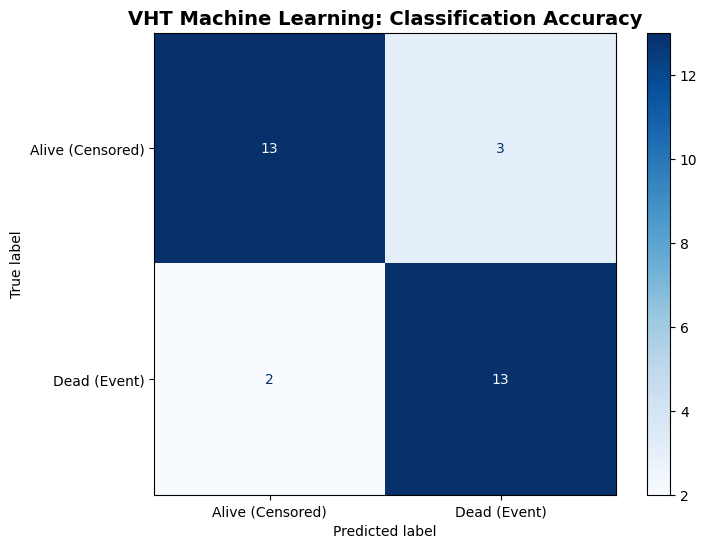

 VHT Matrix Complete: 46 components explain 99% variance.

 TOP DRIVERS OF VHT SIGNATURE (PC1):
Index(['Cycle length of Additional Therapy (q days)', 'Number of Fractions',
       'Number of Days from Diagnosis to Starting Additional Therapy ',
       'Number of days from Diagnosis to date of Further Progression',
       'Number of Days from Diagnosis to Starting 2nd_Additional Therapy ',
       'Number of Days from Diagnosis to Start Immunotherapy ',
       'Multiple surgeries', 'Days from Diagnosis to new treatment',
       ' Number of days from Diagnosis to Initial Chemo Therapy end date',
       'Number of days from Diagnosis to date of First Progression'],
      dtype='object')


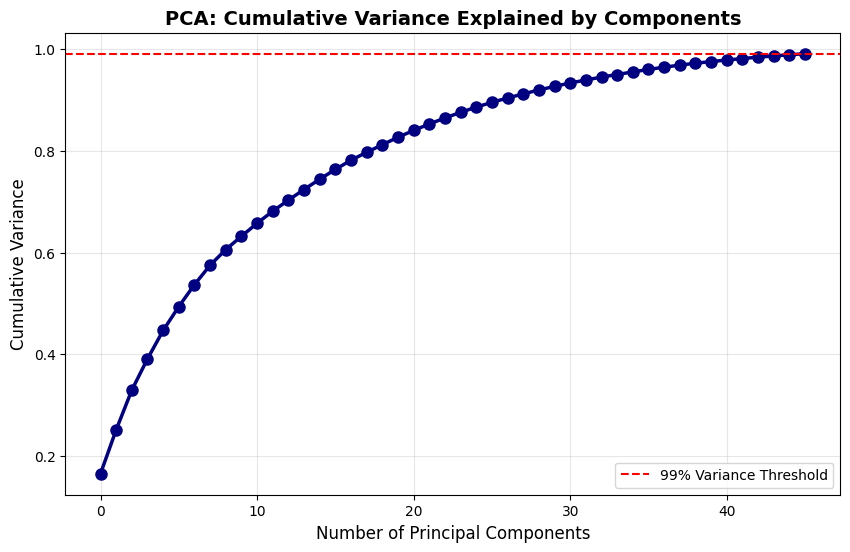

/var/folders/b9/x77syzb94gdggfcpp713pvjm0000gn/T/ipykernel_43766/3832089938.py:260: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=pc1_loadings.head(10).index, x=pc1_loadings.head(10).values, palette='viridis')


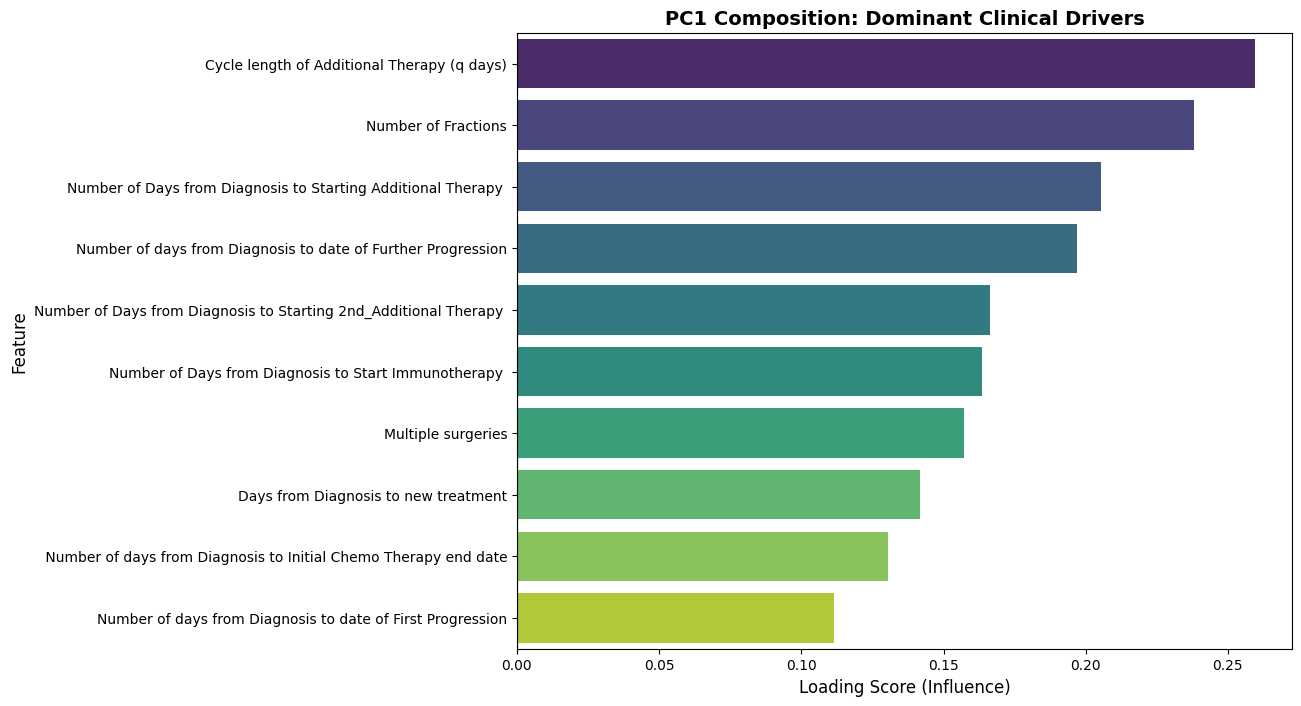

<lifelines.CoxPHFitter: fitted with 203 total observations, 106 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 203
number of events observed = 97
   partial log-likelihood = -340.22
         time fit was run = 2026-05-11 19:58:45 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
PC1       -0.20      0.82      0.04           -0.27           -0.13                0.77                0.88
PC2       -0.20      0.82      0.06           -0.31           -0.09                0.73                0.92
PC3       -0.07      0.93      0.05           -0.16            0.03                0.85                1.03
PC4        0.01      1.01      0.06           -0.11            0.13                0.89                1.14
PC5        0.06      1.06      0.05           -0.05            0.16                0.95                1.18
PC6        0.08      1.08      0.07           -0.06            0.22                0.94                1.25
PC7        0.07      1.08      0.06           -0.05            0.20                0.95                1.22
PC8        0.11      1.12      0.07           -0.02            0.24                0.98                1.27
PC9       -0.06      0.94      0.09           -0.24            0.11                0.79                1.12
PC10       0.05      1.06      0.10           -0.14            0.25                0.87                1.28
PC11       0.01      1.01      0.08           -0.16            0.17                0.85                1.19
PC12       0.14      1.15      0.10           -0.05            0.34                0.95                1.40
PC13      -0.01      0.99      0.09           -0.19            0.17                0.83                1.19
PC14      -0.08      0.92      0.11           -0.29            0.13                0.75                1.14
PC15      -0.29      0.75      0.11           -0.51           -0.07                0.60                0.93
PC16      -0.02      0.98      0.10           -0.22            0.17                0.80                1.19
PC17       0.02      1.02      0.11           -0.20            0.24                0.82                1.27
PC18       0.10      1.10      0.12           -0.13            0.32                0.88                1.38
PC19       0.25      1.28      0.12            0.02            0.48                1.02                1.62
PC20       0.10      1.10      0.13           -0.16            0.35                0.85                1.42
PC21       0.09      1.09      0.11           -0.14            0.31                0.87                1.37
PC22       0.34      1.40      0.14            0.05            0.62                1.05                1.86
PC23      -0.13      0.88      0.14           -0.40            0.15                0.67                1.16
PC24       0.17      1.19      0.15           -0.12            0.46                0.89                1.58
PC25      -0.21      0.81      0.17           -0.54            0.13                0.58                1.14
PC26       0.01      1.01      0.14           -0.27            0.29                0.76                1.33
PC27      -0.01      0.99      0.16           -0.32            0.30                0.72                1.35
PC28      -0.03      0.97      0.17           -0.35            0.29                0.70                1.34
PC29      -0.09      0.91      0.16           -0.42            0.23                0.66                1.26
PC30       0.12      1.13      0.16           -0.19            0.43                0.83                1.54
PC31      -0.51      0.60      0.20           -0.90           -0.12                0.41                0.88
PC32       0

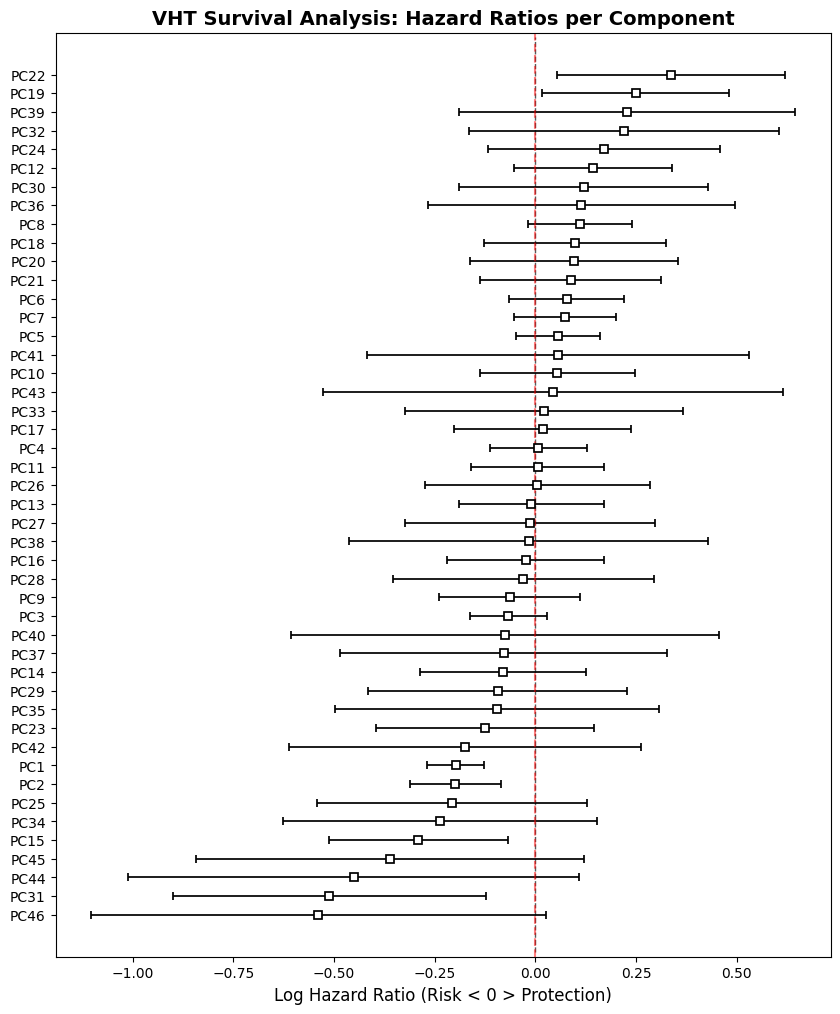

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from lifelines import CoxPHFitter
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ======================================================================================
# 1. SETUP & LONGITUDINAL EXTRACTION (Refined)
# ======================================================================================
image_path = Path("/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post")
seg_vol_path = Path("/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post_Segmentation_Volumes.xlsx")
clinical_path = Path("/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post_ClinicalData-July2025.xlsx")

segmentation_labels = {1: "Necrotic", 2: "Edema", 3: "Enhancing", 4: "Resection"}
label_map = {
    "Necrotic Tumor Core (Label1)": "Necrotic",
    "Tumor Infiltration and Edema": "Edema",
    "Enhancing Tumor Core (Label3)": "Enhancing",
    "Resection Cavity (Label4)": "Resection"
}

# ======================================================================================
# 2. LOAD RADIOMIC MASTER SEQUENCES (Ordered by Patient/Visit)
# ======================================================================================
print(" Extracting longitudinal radiomic sequences...")
# Using a single container for master dicts to prevent variable shadowing
m_dict = {k: {} for k in ['vol', 'vox', 't1cm', 't1cs', 't1nm', 't1ns', 't2fm', 't2fs', 't2wm', 't2ws']}

seg_file = pd.ExcelFile(seg_vol_path)
for sheet in seg_file.sheet_names:
    df = pd.read_excel(seg_vol_path, sheet_name=sheet)
    df.columns = df.columns.str.strip()
    
    if 'Patient ID' in df.columns:
        df['PID_Clean'] = df['Patient ID'].astype(str).str.split('-').str[0]
        label_key = label_map.get(sheet, sheet)
        group = df.groupby('PID_Clean')
        
        # Mapping by index (3-12) ensures robustness against slight naming changes in Excel
        m_dict['vox'][label_key]  = group[df.columns[3]].apply(list).to_dict()
        m_dict['vol'][label_key]  = group[df.columns[4]].apply(list).to_dict()
        m_dict['t1cm'][label_key] = group[df.columns[5]].apply(list).to_dict()
        m_dict['t1cs'][label_key] = group[df.columns[6]].apply(list).to_dict()
        m_dict['t1nm'][label_key] = group[df.columns[7]].apply(list).to_dict()
        m_dict['t1ns'][label_key] = group[df.columns[8]].apply(list).to_dict()
        m_dict['t2fm'][label_key] = group[df.columns[9]].apply(list).to_dict()
        m_dict['t2fs'][label_key] = group[df.columns[10]].apply(list).to_dict()
        m_dict['t2wm'][label_key] = group[df.columns[11]].apply(list).to_dict()
        m_dict['t2ws'][label_key] = group[df.columns[12]].apply(list).to_dict()

clinical_df = pd.read_excel(clinical_path, sheet_name='MU Glioma Post')
clinical_df['PID_Clean'] = clinical_df['Patient ID'].astype(str).str.split('-').str[0]
clinical_data = clinical_df.set_index('PID_Clean').to_dict(orient='index')

patient_ids = sorted([d for d in os.listdir(image_path) if (image_path/d).is_dir() and not d.startswith('.')])
patient_objects = {}

print(" Building integrated VHT Patient objects...")
for pid in patient_ids:
    clean_id = pid.split('-')[0]
    p_folder = image_path / pid
    tps = sorted([t.name for t in p_folder.iterdir() if t.is_dir() and not t.name.startswith('.')])
    
    obj = {
        'Patient_ID': pid, 
        'clinical': clinical_data.get(clean_id, {}), 
        'timepoints': tps,
        'images': {}, 'volumes': {}, 'voxels': {},
        't1c_mean': {}, 't1c_stdevs': {}, 't1n_mean': {}, 't1n_stdevs': {},
        't2f_mean': {}, 't2f_stdevs': {}, 't2w_mean': {}, 't2w_stdevs': {}
    }

    for i, tp in enumerate(tps):
        obj['images'][tp] = [str(f) for f in (p_folder/tp).glob("*.nii*")]
        for l_name in m_dict['vol'].keys():
            # Helper to pull the i-th scan in the sequence safely
            def get_val(key): 
                seq = m_dict[key].get(l_name, {}).get(clean_id, [])
                return seq[i] if i < len(seq) else 0

            obj['volumes'].setdefault(tp, {})[l_name] = float(get_val('vol'))
            obj['voxels'].setdefault(tp, {})[l_name] = int(get_val('vox'))
            obj['t1c_mean'].setdefault(tp, {})[l_name] = float(get_val('t1cm'))
            obj['t1c_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t1cs'))
            obj['t1n_mean'].setdefault(tp, {})[l_name] = float(get_val('t1nm'))
            obj['t1n_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t1ns'))
            obj['t2f_mean'].setdefault(tp, {})[l_name] = float(get_val('t2fm'))
            obj['t2f_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t2fs'))
            obj['t2w_mean'].setdefault(tp, {})[l_name] = float(get_val('t2wm'))
            obj['t2w_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t2ws'))
    
    patient_objects[pid] = obj

# ======================================================================================
# 3. FEATURE ENGINEERING: TRANSFORM KINETICS INTO SCALARS
# ======================================================================================
print(" Converting Longitudinal Kinetics into VHT Behavioral Features...")
kinetic_features = []

for pid, obj in patient_objects.items():
    clean_id = pid.split('-')[0]
    history = None
    
    rates = {f"Vel_{lbl}": [] for lbl in label_map.values()}
    intensity_drifts = {f"Drift_{lbl}_{seq}_{stat}": [] 
                        for lbl in label_map.values() 
                        for seq in ['t1c', 't2f', 't1n', 't2w']
                        for stat in ['mean', 'stdev']}

    # Ensure timepoints are sorted (e.g., Post-treatment_1, _2, _3)
    for tp in sorted(obj['timepoints']):
        # Extract digits: "Post-treatment_1" -> "1"
        tp_num = "".join(filter(str.isdigit, tp))
        
        # --- FIX: Find the correct key in the clinical dict that contains (Timepoint_X) ---
        # We look for any key that has "Timepoint_1", "Timepoint_2", etc. inside it
        day_key = [k for k in obj['clinical'].keys() if f"Timepoint_{tp_num}" in k]
        day = float(obj['clinical'][day_key[0]]) if day_key else np.nan
        
        if history and not np.isnan(day) and not np.isnan(history['day']):
            dt = day - history['day']
            
            # Only calculate if there is a measurable gap in time
            if dt > 0:
                for lbl in label_map.values():
                    # 1. Growth Velocity
                    v_now = obj['volumes'].get(tp, {}).get(lbl, 0)
                    v_prev = history['vols'].get(lbl, 0)
                    rates[f"Vel_{lbl}"].append((v_now - v_prev) / dt)
                    
                    # 2. Intensity Drifts (Mean & Stdev)
                    # Helper to map sequences to internal object keys
                    seq_map = [
                        ('t1c', 't1c_mean', 't1c_stdevs'),
                        ('t2f', 't2f_mean', 't2f_stdevs'),
                        ('t1n', 't1n_mean', 't1n_stdevs'),
                        ('t2w', 't2w_mean', 't2w_stdevs')
                    ]
                    
                    for seq_short, mean_key, std_key in seq_map:
                        # Mean Drift
                        m_now = obj[mean_key].get(tp, {}).get(lbl, 0)
                        m_prev = history[f'{seq_short}_m'].get(lbl, 0)
                        intensity_drifts[f"Drift_{lbl}_{seq_short}_mean"].append((m_now - m_prev) / dt)
                        
                        # Stdev Drift
                        s_now = obj[std_key].get(tp, {}).get(lbl, 0)
                        s_prev = history[f'{seq_short}_s'].get(lbl, 0)
                        intensity_drifts[f"Drift_{lbl}_{seq_short}_stdev"].append((s_now - s_prev) / dt)

        # Update history for the next timepoint comparison
        history = {
            'day': day, 
            'vols': obj['volumes'].get(tp, {}),
            't1c_m': obj['t1c_mean'].get(tp, {}), 't1c_s': obj['t1c_stdevs'].get(tp, {}),
            't2f_m': obj['t2f_mean'].get(tp, {}), 't2f_s': obj['t2f_stdevs'].get(tp, {}),
            't1n_m': obj['t1n_mean'].get(tp, {}), 't1n_s': obj['t1n_stdevs'].get(tp, {}),
            't2w_m': obj['t2w_mean'].get(tp, {}), 't2w_s': obj['t2w_stdevs'].get(tp, {})
        }

    # Aggregate lists into mean scalars
    vht_row = {'PID_Clean': clean_id}
    for k, v in rates.items(): vht_row[k] = np.mean(v) if v else 0
    for k, v in intensity_drifts.items(): vht_row[k] = np.mean(v) if v else 0
    kinetic_features.append(vht_row)

df_kinetics = pd.DataFrame(kinetic_features)

# ======================================================================================
# 4. MERGING & CLEANING FOR ML
# ======================================================================================
df_clinical = pd.read_excel(clinical_path, sheet_name='MU Glioma Post')
df_clinical['PID_Clean'] = df_clinical['Patient ID'].astype(str).str.split('-').str[0]

# Combine Baseline Clinical + Engineered Kinetic Rates
#df_vht = pd.merge(df_clinical, df_kinetics, on='PID_Clean', how='inner')
df_vht = df_clinical

# Identify targets and drop metadata
targets = ['Overall Survival (Death)', 'Number of days from Diagnosis to death (Days)']
exclude = targets + ['Patient ID', 'PID_Clean', 'Hospice', 'Time to First Progression (Days)', 'Progression',
    'Type of 1st Progression',             # Outcome variable
    'Second Progression/Recurrence',    # Outcome variable
    'Type of 2nd Progression',         # Outcome variable
    'Second Progression/Recurrence',    # Outcome variable
    'Number of Days from Diagnosis to 1st MRI (Timepoint_1) ',  # Time variable
    'Number of Days from Diagnosis to 2nd MRI (Timepoint_2) ',  # Time variable
    'Number of Days from Diagnosis to 3rd MRI (Timepoint_3) ',  # Time variable
    'Number of Days from Diagnosis to 4th MRI (Timepoint_4) ',  # Time variable
    'Number of Days from Diagnosis to 5th MRI (Timepoint_5) ',  # Time variable
    'Number of Days from Diagnosis to 6th MRI (Timepoint_6) '   # Time variable
]
X_raw = df_vht.drop(columns=[c for c in exclude if c in df_vht.columns])

# Standard Preprocessing
for col in X_raw.select_dtypes(include=['object']).columns:
    X_raw[col] = LabelEncoder().fit_transform(X_raw[col].astype(str))
X_raw = X_raw.fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
pca = PCA(n_components=0.99)
X_pca = pca.fit_transform(X_scaled)

# Prepare y for the split to ensure we reference the actual data, not the name list
y_labels = df_vht[targets[0]].astype(int)

X_train_pca, X_test_pca, y_train, y_test = train_test_split(
    X_pca, y_labels, test_size=0.15, random_state=42, stratify=y_labels
)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_pca, y_train)

clf_pca = GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=4, random_state=42)
clf_pca.fit(X_train_smote, y_train_smote)

# We use y_test (actual values) instead of targets (list of names)
y_pred = clf_pca.predict(X_test_pca)
cm = confusion_matrix(y_test, y_pred)

# Plotting fix: disp.plot creates its own axis, we just need to set the title after
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Alive (Censored)', 'Dead (Event)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d', ax=ax)

plt.title('VHT Machine Learning: Classification Accuracy', fontsize=14, fontweight='bold')
plt.show()

# ======================================================================================
# 5. VHT SIGNATURE ANALYSIS (PCA)
# ======================================================================================
print(f" VHT Matrix Complete: {X_pca.shape[1]} components explain 99% variance.")

# Show top drivers of PC1 (Now includes Velocities!)
pc1_drivers = pd.Series(pca.components_[0], index=X_raw.columns).sort_values(ascending=False)
print("\n TOP DRIVERS OF VHT SIGNATURE (PC1):")
print(pc1_drivers.head(10).index)

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), 'o-', color='navy', linewidth=2.5, markersize=8)
plt.axhline(y=0.99, color='red', linestyle='--', label='99% Variance Threshold')
plt.title('PCA: Cumulative Variance Explained by Components', fontsize=14, fontweight='bold')
plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Cumulative Variance', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 8))
pc1_loadings = pd.Series(pca.components_[0], index=X_raw.columns).sort_values(ascending=False)
sns.barplot(y=pc1_loadings.head(10).index, x=pc1_loadings.head(10).values, palette='viridis')
plt.title('PC1 Composition: Dominant Clinical Drivers', fontsize=14, fontweight='bold')
plt.xlabel('Loading Score (Influence)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

# ======================================================================================
# 6. SURVIVAL MODELING (COX PCA)
# ======================================================================================
df_cox_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
df_cox_pca['duration'] = df_vht['Number of days from Diagnosis to death (Days)'].fillna(df_vht['Time to First Progression (Days)']).fillna(1).values
df_cox_pca['event'] = df_vht['Overall Survival (Death)'].astype(int).values

cph = CoxPHFitter(penalizer=0.1)
cph.fit(df_cox_pca[df_cox_pca['duration'] > 0], duration_col='duration', event_col='event')
cph.print_summary()

# D. COX HAZARD RATIO FOREST PLOT
plt.figure(figsize=(10, 12))
cph.plot()
plt.title('VHT Survival Analysis: Hazard Ratios per Component', fontsize=14, fontweight='bold')
plt.xlabel('Log Hazard Ratio (Risk < 0 > Protection)', fontsize=12)
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.show()

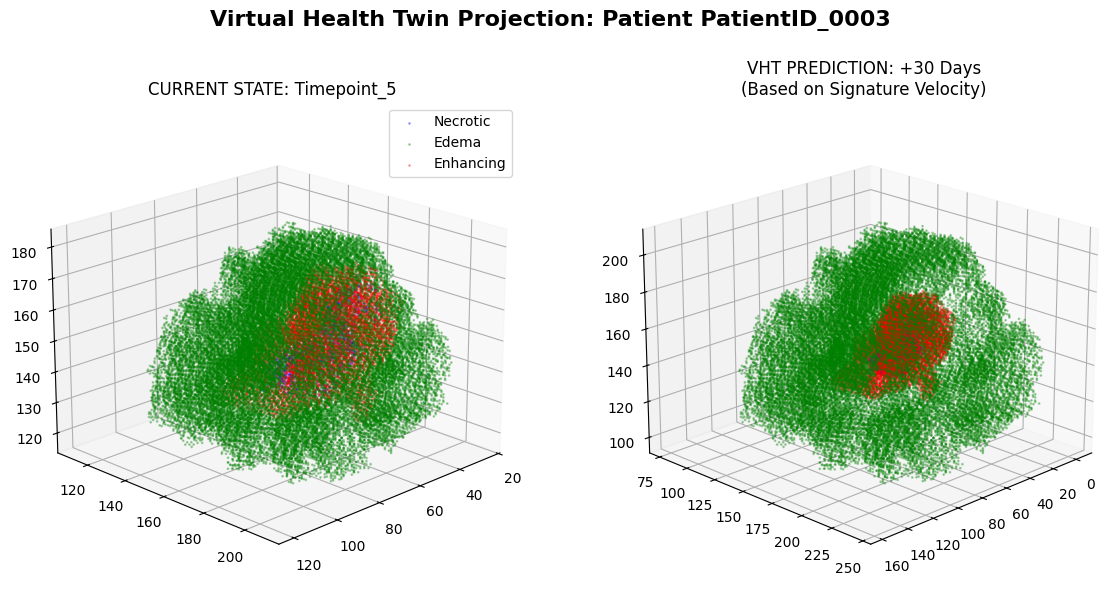

In [18]:
import nibabel as nib
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

# --- Step A: Train the Forecaster (Mapping PCA to Multi-Compartment Growth) ---
forecast_targets = ['Vel_Necrotic', 'Vel_Edema', 'Vel_Enhancing', 'Vel_Resection']
y_forecast = df_kinetics[forecast_targets]
forecaster = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42))
forecaster.fit(X_pca, y_forecast)

def visualize_vht_3d_prediction(patient_idx, days=30):
    pid_clean = df_kinetics.iloc[patient_idx]['PID_Clean']
    
    # 1. Get the actual patient object and the latest mask
    # Find the full PID string from the patient_objects dict
    full_pid = next(k for k in patient_objects.keys() if pid_clean in k)
    patient = patient_objects[full_pid]
    latest_tp = sorted(patient['timepoints'])[-1]
    
    image_list = patient['images'].get(latest_tp, [])
    mask_path = next((p for p in image_list if "mask" in Path(p).name.lower()), None)
    
    if not mask_path:
        print(f"No mask found for {pid_clean} to perform 3D projection.")
        return

    # 2. Predict Future Velocities
    signature = X_pca[patient_idx].reshape(1, -1)
    predicted_vels = forecaster.predict(signature)[0]
    vel_map = dict(zip([1, 2, 3, 4], predicted_vels)) # Map to Label IDs

    # 3. Load Mask Data
    img_obj = nib.load(mask_path)
    mask_data = img_obj.get_fdata()
    
    # 4. Visualization Setup
    fig = plt.figure(figsize=(14, 7))
    colors = {1: "blue", 2: "green", 3: "red", 4: "yellow"}
    labels = {1: "Necrotic", 2: "Edema", 3: "Enhancing", 4: "Resection"}

    # Subplot 1: CURRENT STATE
    ax1 = fig.add_subplot(121, projection='3d')
    for lvl, color in colors.items():
        z, y, x = np.where(mask_data == lvl)
        if len(x) > 0:
            ax1.scatter(x[::5], y[::5], z[::5], c=color, s=1, alpha=0.3, label=labels[lvl])
    ax1.set_title(f"CURRENT STATE: {latest_tp}")
    ax1.legend()

    # Subplot 2: VHT PREDICTED STATE
    ax2 = fig.add_subplot(122, projection='3d')
    for lvl, color in colors.items():
        z, y, x = np.where(mask_data == lvl)
        if len(x) > 0:
            # VHT Projection Logic:
            # If velocity is positive, we "dilate" the points outward slightly
            # If negative, we "contract" them. 
            # This is a visual representation of the predicted volume change.
            scale_factor = 1 + (vel_map[lvl] * days / 10000) # Norm factor for visualization
            
            x_pred = (x - np.mean(x)) * scale_factor + np.mean(x)
            y_pred = (y - np.mean(y)) * scale_factor + np.mean(y)
            z_pred = (z - np.mean(z)) * scale_factor + np.mean(z)
            
            ax2.scatter(x_pred[::5], y_pred[::5], z_pred[::5], c=color, s=1, alpha=0.3)
            
    ax2.set_title(f"VHT PREDICTION: +{days} Days\n(Based on Signature Velocity)")
    
    # Sync view angles
    ax1.view_init(20, 45); ax2.view_init(20, 45)
    plt.suptitle(f"Virtual Health Twin Projection: Patient {pid_clean}", fontsize=16, fontweight='bold')
    plt.show()

# Run the 3D Projection
visualize_vht_3d_prediction(patient_idx=0, days=30)